# **HR-Employee-Attrition Prediction using Machine Learning(Classification)**

HR Employee attrition is an important issue faced by many companies today. When employees leave, it affects the company’s performance and increases the cost of hiring new employees. Understanding the reasons behind attrition is very necessary.

This project uses Machine Learning to predict employee attrition based on different factors such as salary, job role, job satisfaction, overtime, and work-life balance.

The goal of this project is to help organizations identify employees who are likely to leave and take actions to retain them.

# Problem Statement

Employee attrition is a major challenge for organizations as it leads to loss of skilled employees, increased recruitment costs, and reduced productivity. It becomes difficult for companies to identify which employees are likely to leave based on various factors like job satisfaction, salary, work-life balance, and overtime.

To overcome this issue, a Machine Learning classification model can be developed to predict employee attrition (Yes/No). By analyzing employee data and identifying important factors affecting attrition, the model helps organizations take preventive actions such as improving work conditions, offering better benefits, and increasing employee satisfaction. This enables companies to reduce attrition and improve overall performance.

# Objective
The main Objective of this project is

analyze the employee

*   analyze the employee dataset and understand its features

*  clean the data by removing missing values and duplicate records

*   handle outliers for improving data quality
*   perform data visualization and analysis (EDA)


*  convert categorical data into numerical form using encoding

* normalize the data for better model accuracy
* build and train different classification models
* compare model performance using evaluation metrics
* improve model performance using cross-validation and tuning
* identify and select the most accurate model for predicting employee attrition

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [ ]:
data = pd.read_csv('HR-Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Data Handling

In [ ]:
data.shape #Shows the number of rows and columns in the dataset.

(1470, 35)

In [ ]:
data.columns #Displays the names of all columns in the dataset.

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
data.dtypes #it shows the datatype of allcolumns

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
# is a Pandas function used to select only the columns that have the data type int64 (integer values) from the dataset.
num_cols = data.select_dtypes(include=['int64'])
num_cols

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,2,1,1,2,94,3,2,...,1,80,0,8,0,1,6,4,0,5
1,49,279,8,1,1,2,3,61,2,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1373,2,2,1,4,4,92,2,1,...,2,80,0,7,3,3,0,0,0,0
3,33,1392,3,4,1,5,4,56,3,1,...,3,80,0,8,3,3,8,7,3,0
4,27,591,2,1,1,7,1,40,3,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,1,2061,3,41,4,2,...,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,1,2062,4,42,2,3,...,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,1,2064,2,87,4,2,...,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,1,2065,4,63,2,2,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
cat_cols = data.select_dtypes(include=['object']) #is a Pandas function used to select all the columns that have the object data type, which usually represents categorical or text data.
data.describe()
cat_cols

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [ ]:
data.describe() # it provide starestical information

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Handle Missing Values

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# Handle Duplicate Records

In [ ]:
data.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

**Univariate Analysis:** Univariate Analysis is the process of analyzing a single variable at a time to understand its distribution, pattern, and basic characteristics.

Distribution of numerical features: such as

* Age
* DailyRate
* DistanceFromHome
* Education
* EmployeeCount
* EmployeeNumber
* RelationshipSatisfaction
* StandardHours
* StockOptionLevel
* TotalWorkingYears
* TrainingTimesLastYear
* WorkLifeBalance
* YearsAtCompany
* YearsInCurrentRole
* YearsSinceLastPromotion
* YearsWithCurrManager
* JobInvolvement
* JobLevel
* HourlyRate
* EnvironmentSatisfaction
* MonthlyIncome
* MonthlyRate
* NumCompaniesWorked
* PercentSalaryHike
* PerformanceRating
* JobSatisfaction

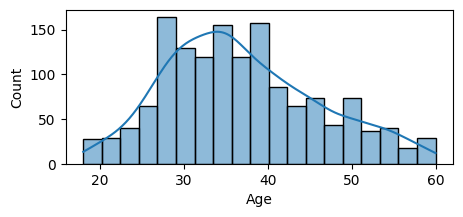

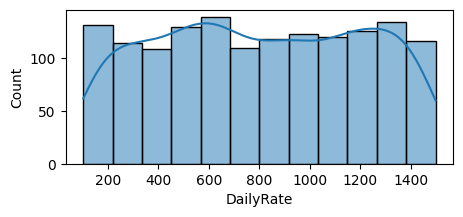

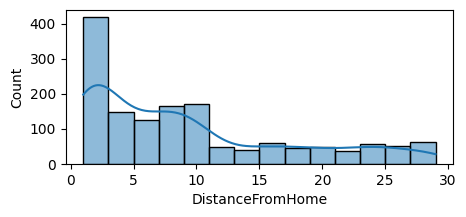

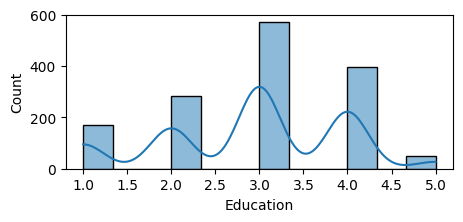

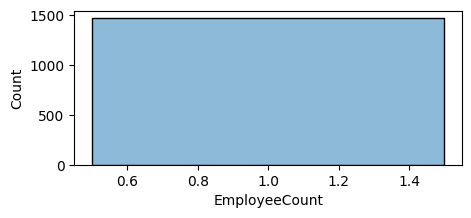

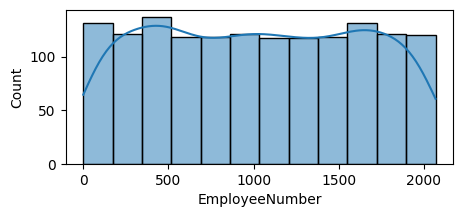

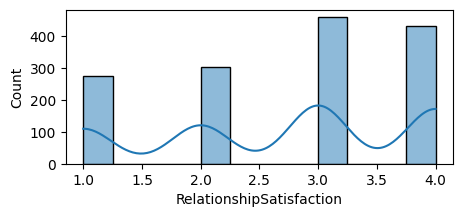

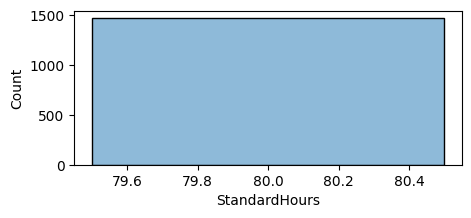

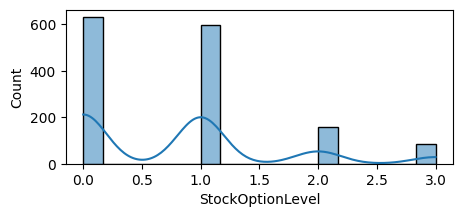

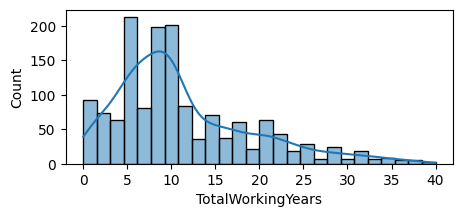

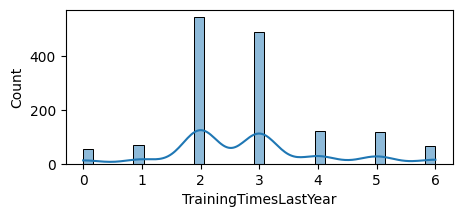

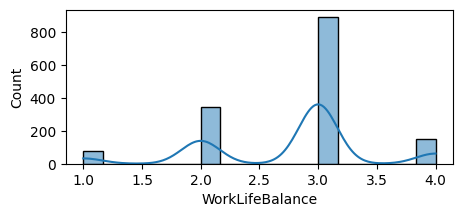

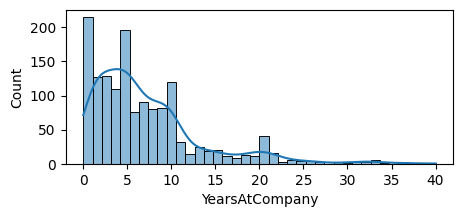

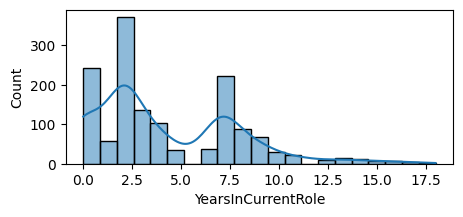

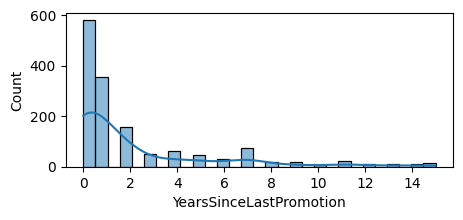

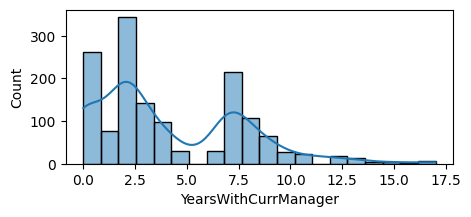

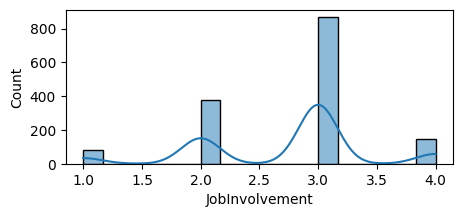

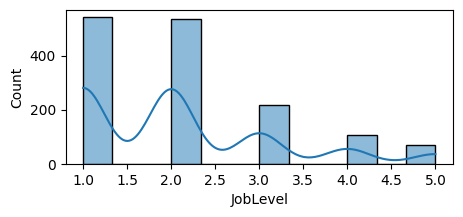

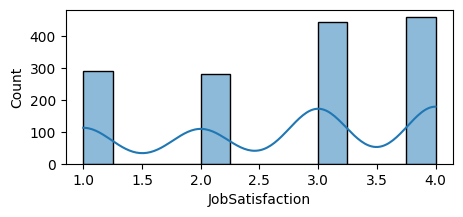

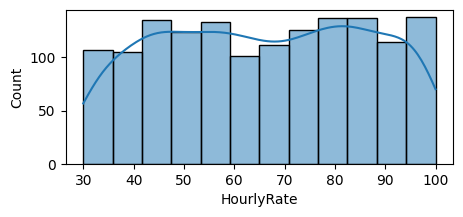

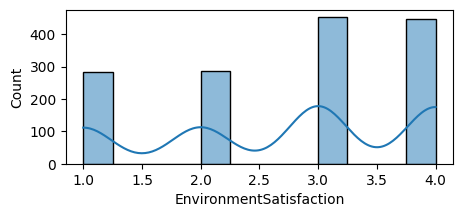

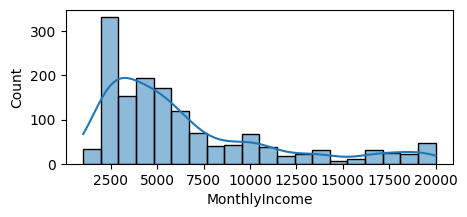

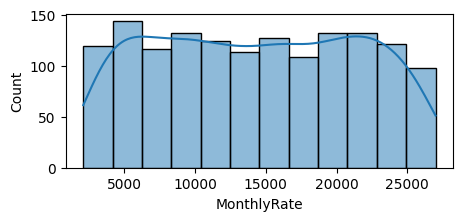

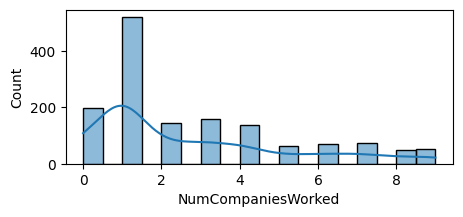

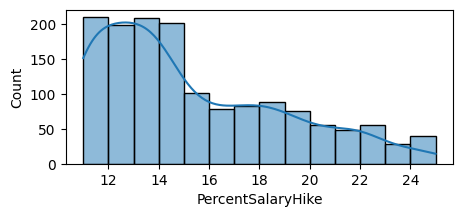

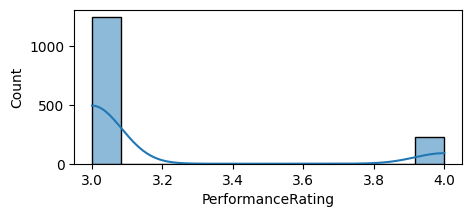

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='Age', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='DailyRate', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='DistanceFromHome', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='Education', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='EmployeeCount', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='EmployeeNumber', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='RelationshipSatisfaction', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='StandardHours', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='StockOptionLevel', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='TotalWorkingYears', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='TrainingTimesLastYear', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='WorkLifeBalance', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='YearsAtCompany', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='YearsInCurrentRole', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='YearsSinceLastPromotion', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='YearsWithCurrManager', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='JobInvolvement', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='JobLevel', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='JobSatisfaction', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='HourlyRate', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='EnvironmentSatisfaction', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='MonthlyIncome', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='MonthlyRate', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='NumCompaniesWorked', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='PercentSalaryHike', kde=True)
plt.show()

plt.figure(figsize=(5,2))
sns.histplot(data, x='PerformanceRating', kde=True)
plt.show()

**Count plots for categorical features:**  A count plot is used for categorical variables to show the frequency (count) of each category in the dataset.

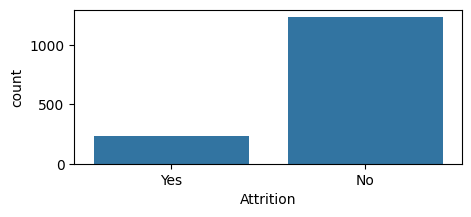

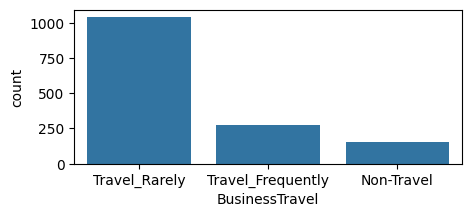

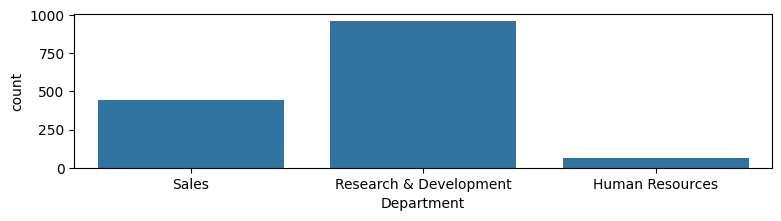

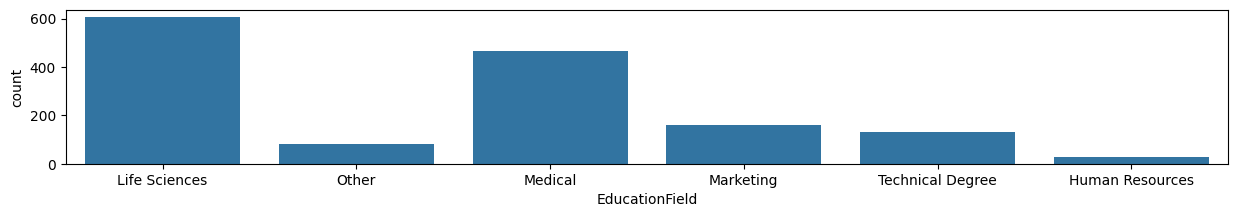

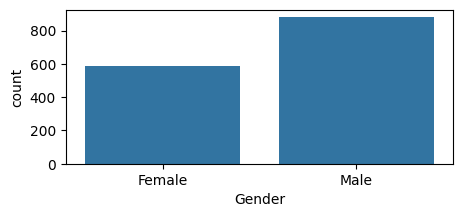

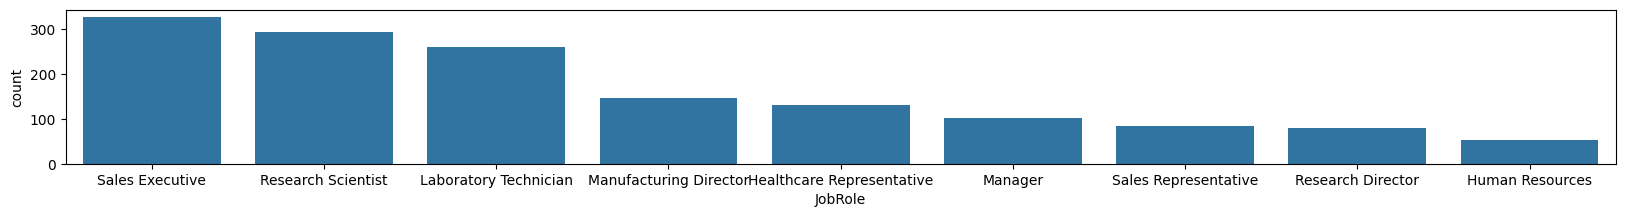

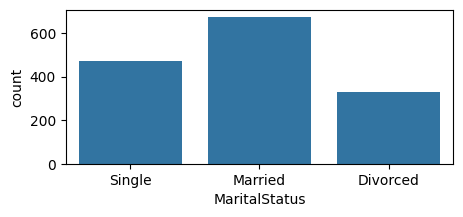

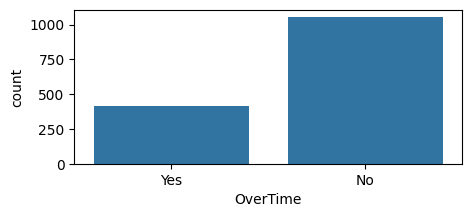

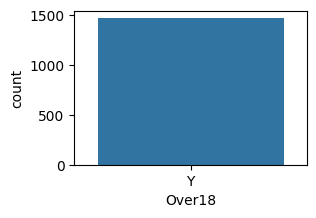

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data, x='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data, x='BusinessTravel')
plt.show()

plt.figure(figsize=(9,2))
sns.countplot(data, x='Department')
plt.show()

plt.figure(figsize=(15,2))
sns.countplot(data, x='EducationField')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data, x='Gender')
plt.show()

plt.figure(figsize=(20,2))
sns.countplot(data, x='JobRole')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data, x='MaritalStatus')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data, x='OverTime')
plt.show()

plt.figure(figsize=(3,2))
sns.countplot(data, x='Over18')
plt.show()

**Bivariate Analysis:** Bivariate Analysis is used to analyze the relationship between two variables (columns) in the dataset. It helps in understanding how one variable affects another and identifies patterns, trends, or correlations between them.

**Attrition vs categorical features**

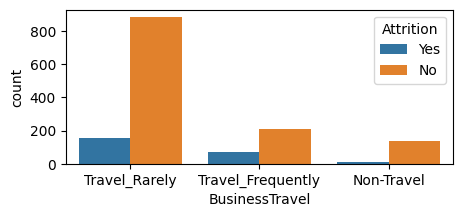

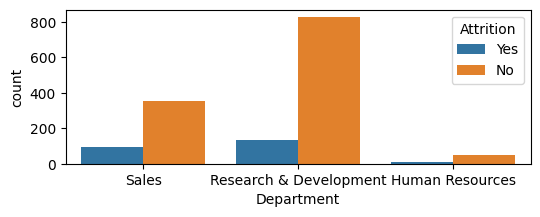

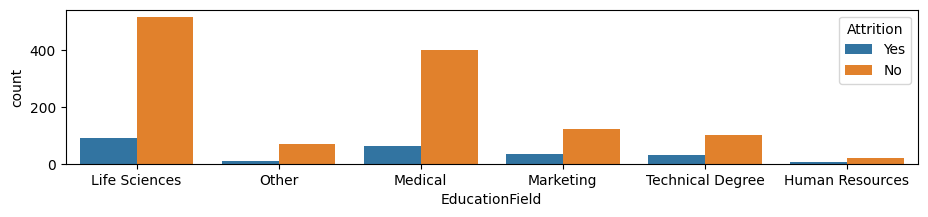

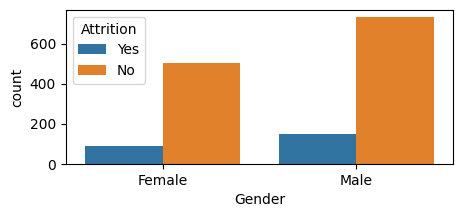

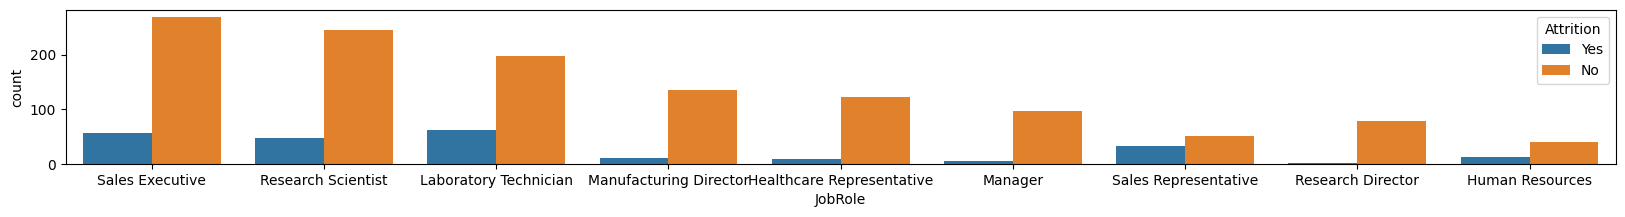

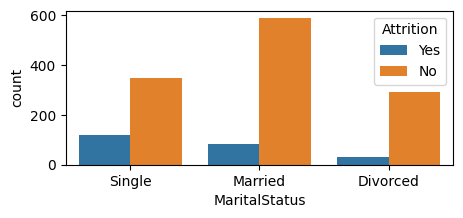

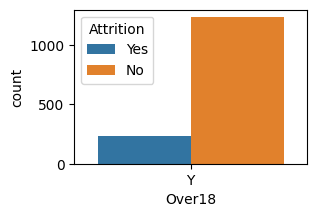

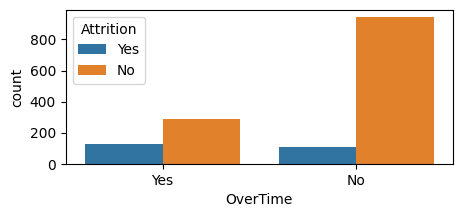

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='BusinessTravel',hue='Attrition')
plt.show()

plt.figure(figsize=(6,2))
sns.countplot(data,x='Department',hue='Attrition')
plt.show()

plt.figure(figsize=(11,2))
sns.countplot(data,x='EducationField',hue='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender',hue='Attrition')
plt.show()

plt.figure(figsize=(20,2))
sns.countplot(data,x='JobRole',hue='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data,x='MaritalStatus',hue='Attrition')
plt.show()

plt.figure(figsize=(3,2))
sns.countplot(data,x='Over18',hue='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.countplot(data,x='OverTime',hue='Attrition')
plt.show()

**Attrition vs numerical features**

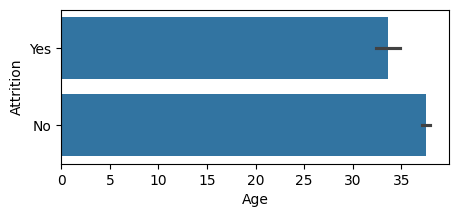

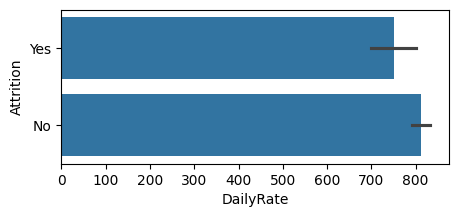

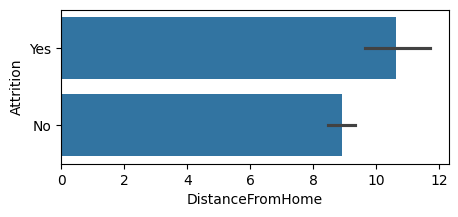

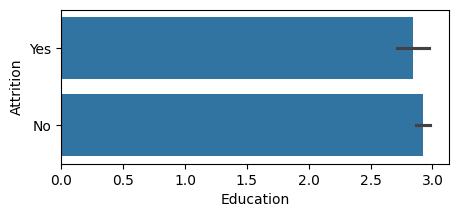

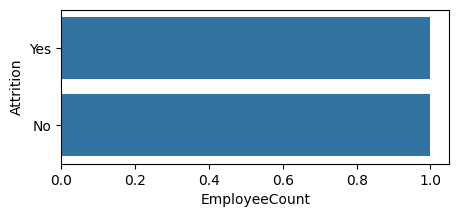

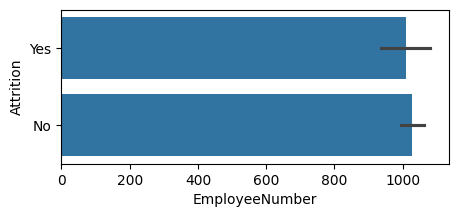

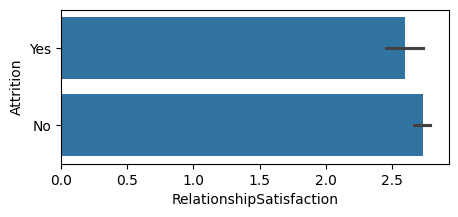

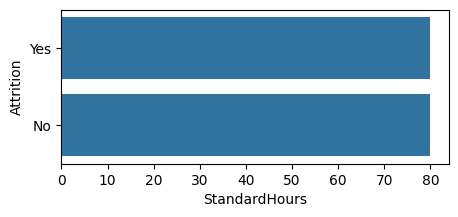

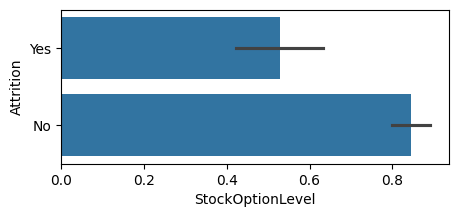

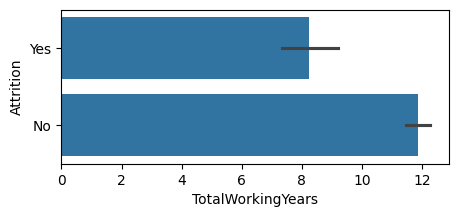

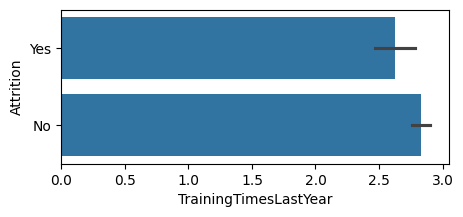

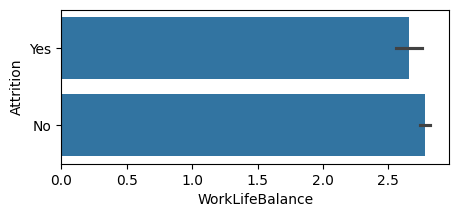

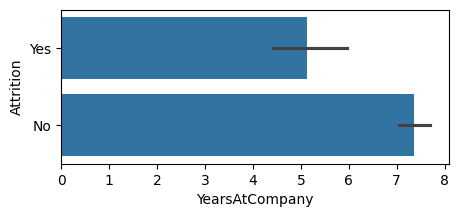

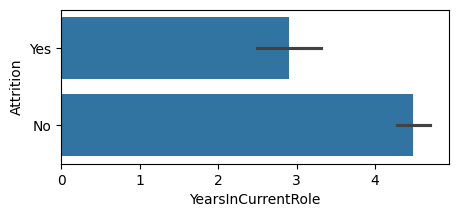

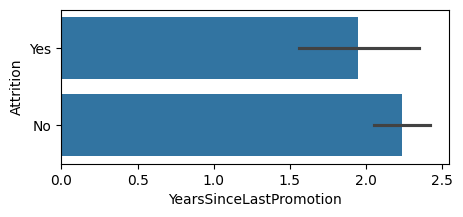

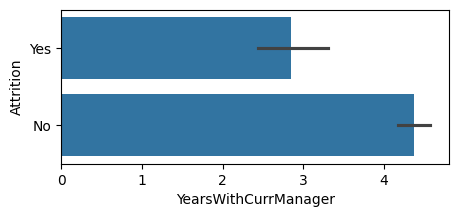

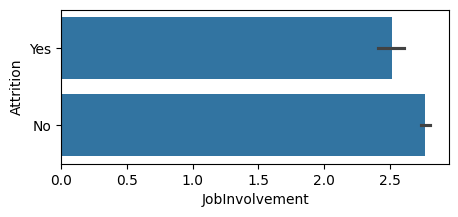

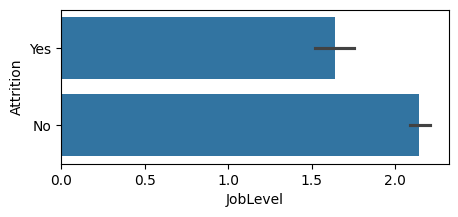

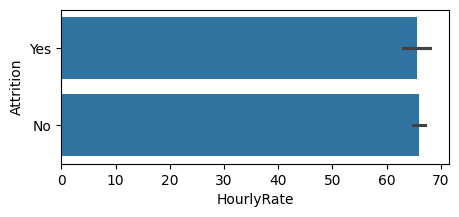

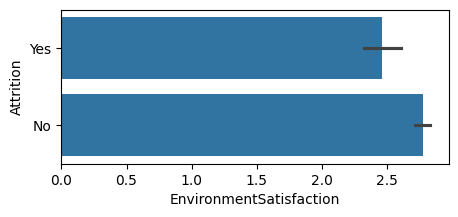

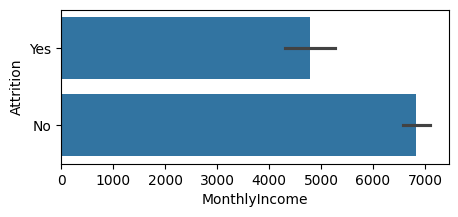

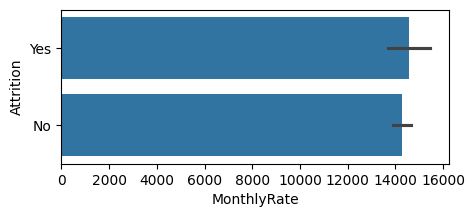

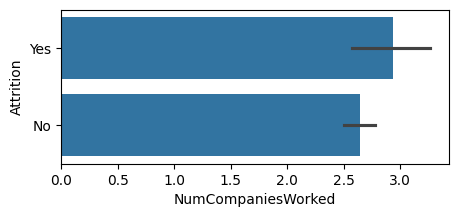

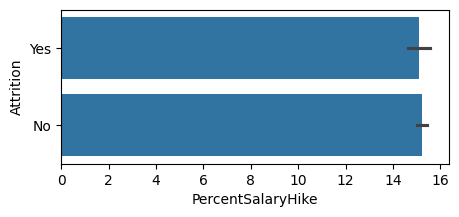

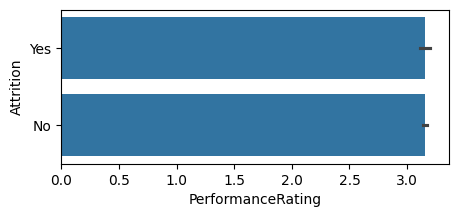

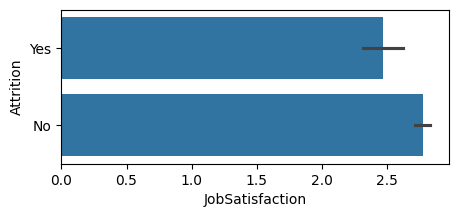

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='Age',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='DailyRate',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='DistanceFromHome',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='Education',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='EmployeeCount',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='EmployeeNumber',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='RelationshipSatisfaction',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='StandardHours',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='StockOptionLevel',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='TotalWorkingYears',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='TrainingTimesLastYear',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='WorkLifeBalance',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='YearsAtCompany',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='YearsInCurrentRole',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='YearsSinceLastPromotion',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='YearsWithCurrManager',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='JobInvolvement',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='JobLevel',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='HourlyRate',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='EnvironmentSatisfaction',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='MonthlyIncome',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='MonthlyRate',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='NumCompaniesWorked',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='PercentSalaryHike',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='PerformanceRating',y='Attrition')
plt.show()

plt.figure(figsize=(5,2))
sns.barplot(data,x='JobSatisfaction',y='Attrition')
plt.show()

# Heatmap

In [ ]:
# finding corr
num_cols.corr()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


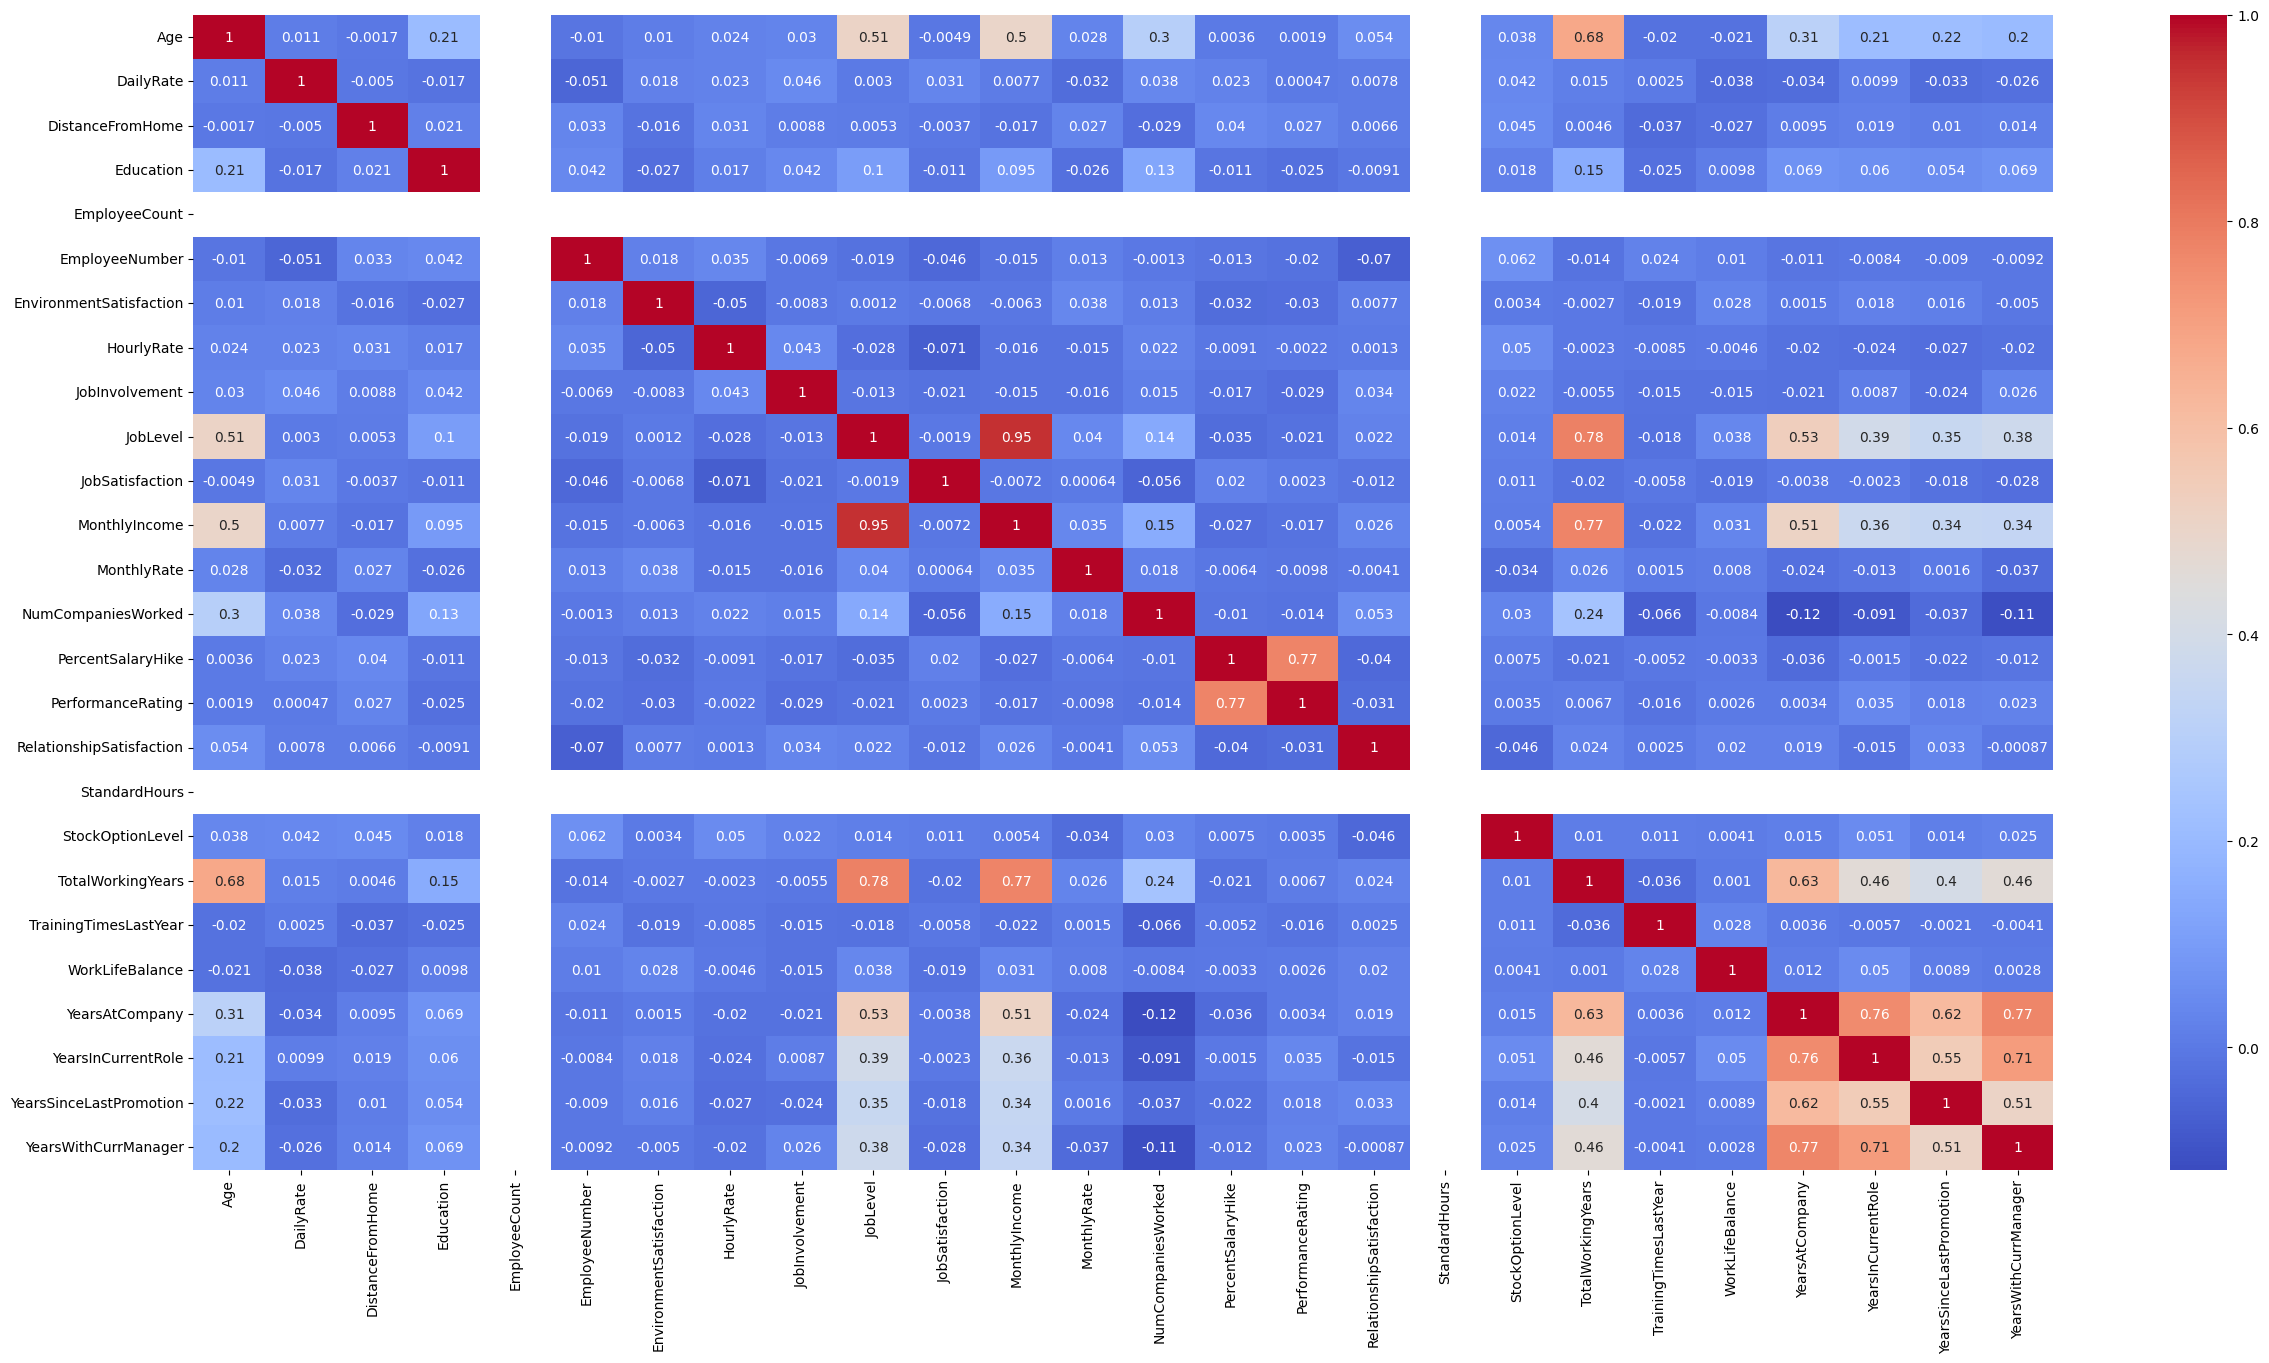

In [ ]:
plt.figure(figsize=(30,15))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

# Handle Outliers

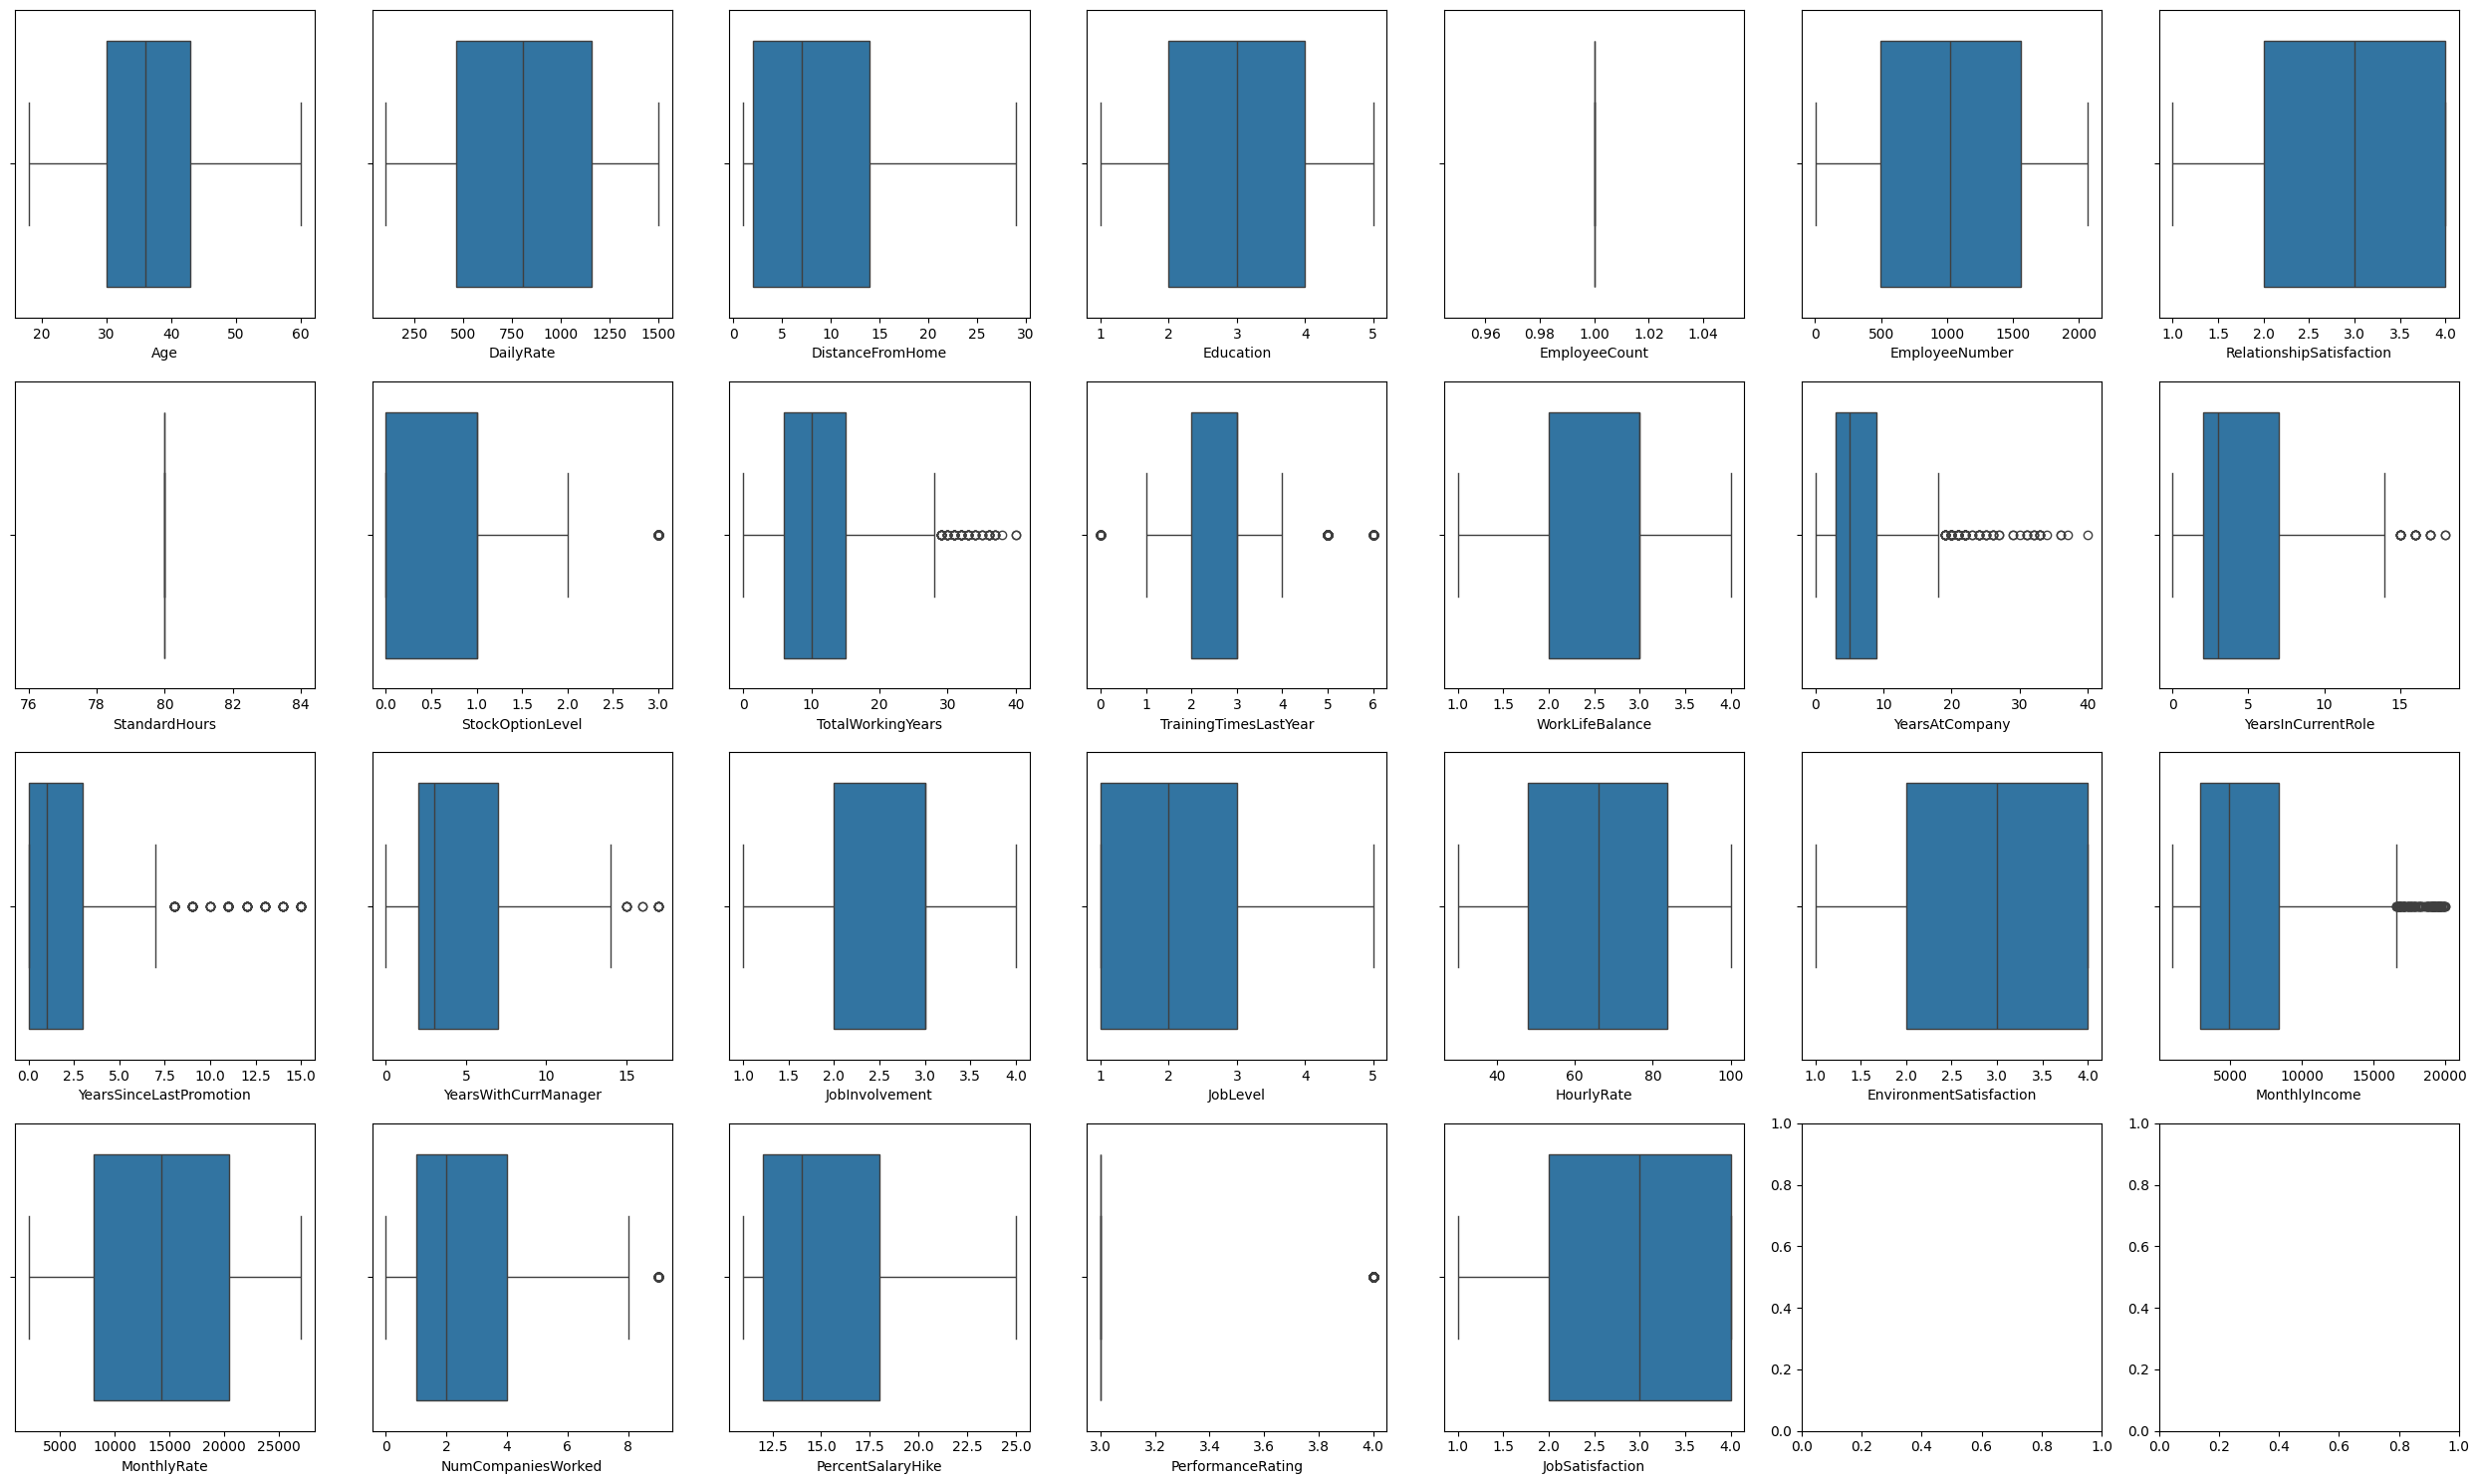

In [ ]:
fig, ax = plt.subplots(4, 7, figsize=(25, 15))  # 4 rows, 7 columns

ax = ax.flatten()


sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='DailyRate',ax=ax[1])
sns.boxplot(data,x='DistanceFromHome',ax=ax[2])
sns.boxplot(data,x='Education',ax=ax[3])
sns.boxplot(data,x='EmployeeCount',ax=ax[4])
sns.boxplot(data,x='EmployeeNumber',ax=ax[5])
sns.boxplot(data,x='RelationshipSatisfaction',ax=ax[6])
sns.boxplot(data,x='StandardHours',ax=ax[7])
sns.boxplot(data,x='StockOptionLevel',ax=ax[8])
sns.boxplot(data,x='TotalWorkingYears',ax=ax[9])
sns.boxplot(data,x='TrainingTimesLastYear',ax=ax[10])
sns.boxplot(data,x='WorkLifeBalance',ax=ax[11])
sns.boxplot(data,x='YearsAtCompany',ax=ax[12])
sns.boxplot(data,x='YearsInCurrentRole',ax=ax[13])
sns.boxplot(data,x='YearsSinceLastPromotion',ax=ax[14])
sns.boxplot(data,x='YearsWithCurrManager',ax=ax[15])
sns.boxplot(data,x='JobInvolvement',ax=ax[16])
sns.boxplot(data,x='JobLevel',ax=ax[17])
sns.boxplot(data,x='HourlyRate',ax=ax[18])
sns.boxplot(data,x='EnvironmentSatisfaction',ax=ax[19])
sns.boxplot(data,x='MonthlyIncome',ax=ax[20])
sns.boxplot(data,x='MonthlyRate',ax=ax[21])
sns.boxplot(data,x='NumCompaniesWorked',ax=ax[22])
sns.boxplot(data,x='PercentSalaryHike',ax=ax[23])
sns.boxplot(data,x='PerformanceRating',ax=ax[24])
sns.boxplot(data,x='JobSatisfaction',ax=ax[25])
plt.tight_layout()
plt.show()

Outliers are present in continuous features such as:

* TotalWorkingYears
* TrainingTimesLastYear
* YearsAtCompany
* YearsInCurrentRole
* YearsSinceLastPromotion
* YearsWithCurrManager
* MonthlyIncome
* NumCompaniesWorked
* StockOptionLevel

In [ ]:
Q1 = data['TotalWorkingYears'].quantile(0.25)
Q3 = data['TotalWorkingYears'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['TotalWorkingYears'] = data['TotalWorkingYears'].clip(lower, upper)

In [ ]:
Q1 = data['TrainingTimesLastYear'].quantile(0.25)
Q3 = data['TrainingTimesLastYear'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['TrainingTimesLastYear'] = data['TrainingTimesLastYear'].clip(lower, upper)

In [ ]:
Q1 = data['YearsAtCompany'].quantile(0.25)
Q3 = data['YearsAtCompany'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsAtCompany'] = data['YearsAtCompany'].clip(lower, upper)

In [ ]:
Q1 = data['YearsInCurrentRole'].quantile(0.25)
Q3 = data['YearsInCurrentRole'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsInCurrentRole'] = data['YearsInCurrentRole'].clip(lower, upper)

In [ ]:
Q1 = data['YearsSinceLastPromotion'].quantile(0.25)
Q3 = data['YearsSinceLastPromotion'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsSinceLastPromotion'] = data['YearsSinceLastPromotion'].clip(lower, upper)

In [ ]:
Q1 = data['YearsWithCurrManager'].quantile(0.25)
Q3 = data['YearsWithCurrManager'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['YearsWithCurrManager'] = data['YearsWithCurrManager'].clip(lower, upper)

In [ ]:
Q1 = data['MonthlyIncome'].quantile(0.25)
Q3 = data['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['MonthlyIncome'] = data['MonthlyIncome'].clip(lower, upper)

In [ ]:
Q1 = data['NumCompaniesWorked'].quantile(0.25)
Q3 = data['NumCompaniesWorked'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['NumCompaniesWorked'] = data['NumCompaniesWorked'].clip(lower, upper)

In [ ]:
Q1 = data['StockOptionLevel'].quantile(0.25)
Q3 = data['StockOptionLevel'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['StockOptionLevel'] = data['StockOptionLevel'].clip(lower, upper)

In [ ]:
Q1 = data['PerformanceRating'].quantile(0.25)
Q3 = data['PerformanceRating'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['PerformanceRating'] = data['PerformanceRating'].clip(lower, upper)

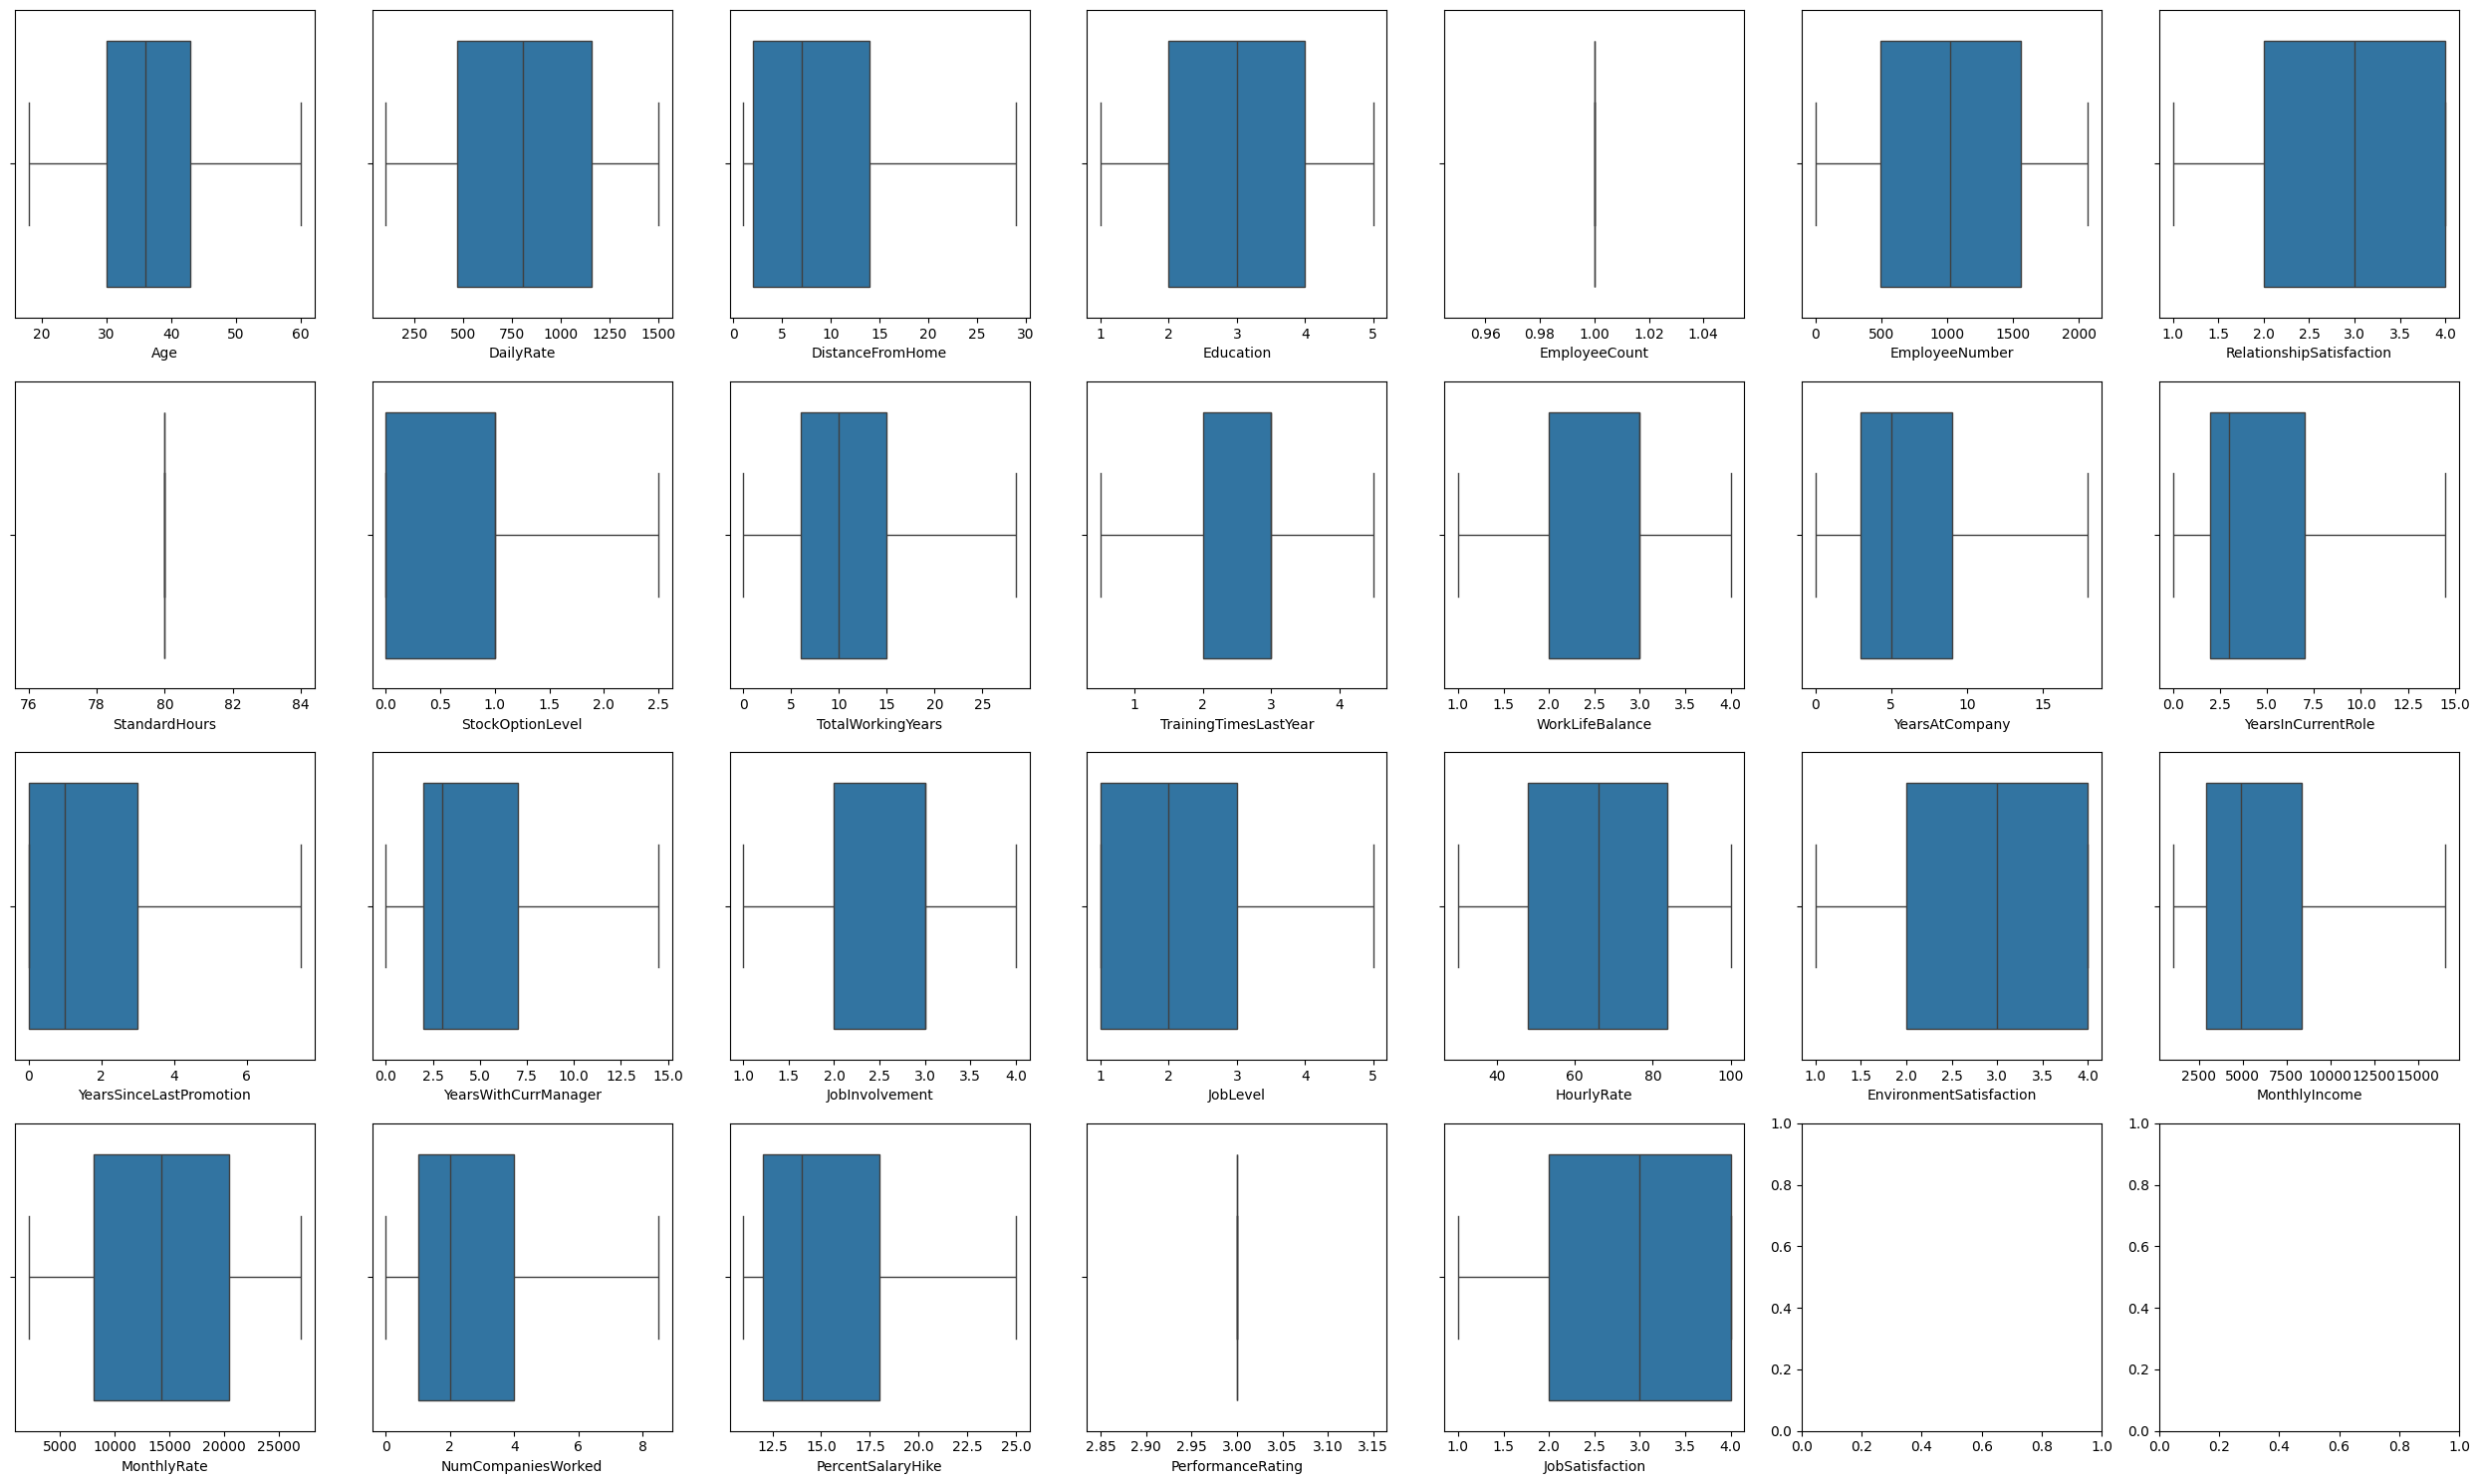

In [ ]:
fig, ax = plt.subplots(4, 7, figsize=(25, 15))  # 4 rows, 7 columns

ax = ax.flatten()


sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='DailyRate',ax=ax[1])
sns.boxplot(data,x='DistanceFromHome',ax=ax[2])
sns.boxplot(data,x='Education',ax=ax[3])
sns.boxplot(data,x='EmployeeCount',ax=ax[4])
sns.boxplot(data,x='EmployeeNumber',ax=ax[5])
sns.boxplot(data,x='RelationshipSatisfaction',ax=ax[6])
sns.boxplot(data,x='StandardHours',ax=ax[7])
sns.boxplot(data,x='StockOptionLevel',ax=ax[8])
sns.boxplot(data,x='TotalWorkingYears',ax=ax[9])
sns.boxplot(data,x='TrainingTimesLastYear',ax=ax[10])
sns.boxplot(data,x='WorkLifeBalance',ax=ax[11])
sns.boxplot(data,x='YearsAtCompany',ax=ax[12])
sns.boxplot(data,x='YearsInCurrentRole',ax=ax[13])
sns.boxplot(data,x='YearsSinceLastPromotion',ax=ax[14])
sns.boxplot(data,x='YearsWithCurrManager',ax=ax[15])
sns.boxplot(data,x='JobInvolvement',ax=ax[16])
sns.boxplot(data,x='JobLevel',ax=ax[17])
sns.boxplot(data,x='HourlyRate',ax=ax[18])
sns.boxplot(data,x='EnvironmentSatisfaction',ax=ax[19])
sns.boxplot(data,x='MonthlyIncome',ax=ax[20])
sns.boxplot(data,x='MonthlyRate',ax=ax[21])
sns.boxplot(data,x='NumCompaniesWorked',ax=ax[22])
sns.boxplot(data,x='PercentSalaryHike',ax=ax[23])
sns.boxplot(data,x='PerformanceRating',ax=ax[24])
sns.boxplot(data,x='JobSatisfaction',ax=ax[25])
plt.tight_layout()
plt.show()

# Encoding Technique
**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Attrition'] = le.fit_transform(data['Attrition'])
data['Gender'] = le.fit_transform(data['Gender'])
data['OverTime'] = le.fit_transform(data['OverTime'])

**One-Hot Encoding**

In [ ]:
cat_cols = data.select_dtypes(include='object').columns

data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Scaling
              Scaling is a preprocessing technique used to bring all numerical features into the same range. It helps machine learning models perform better by ensuring that no feature dominates due to larger values.

**1 StandardScaler**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = data.select_dtypes(include=['int64','float64']).columns

data[num_cols] = scaler.fit_transform(data[num_cols])

**2 MinMaxScaler**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = data.select_dtypes(include=['int64','float64']).columns

data[num_cols] = scaler.fit_transform(data[num_cols])

# Future Selection

In [ ]:
X = data.drop('Attrition', axis=1)
y = data['Attrition']

# Train and Split()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Balance data

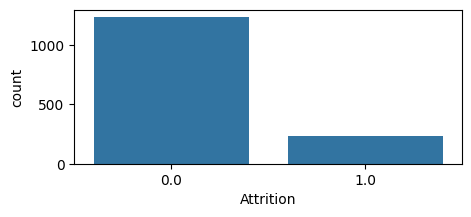

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Attrition')
plt.show()
# data is imbalanced will use SMOTE for balancing

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_sampled,y_sampled = smote.fit_resample(X_train,y_train)
# Balancing should be done only on training data

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_sampled,y_sampled)
y_pred = lr.predict(X_test)

 **Model Evaluation for Logistic Regression**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
y_prob=lr.predict_proba(X_test)[:,1]
y_prob

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7959183673469388
Precision: 0.3220338983050847
Recall: 0.48717948717948717
F1 Score: 0.3877551020408163
ROC-AUC Score: 0.7539467068878833
Confusion Matrix:
 [[215  40]
 [ 20  19]]


# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_sampled ,y_sampled)
y_pred = dt.predict(X_test)

**Model Evaluation for Decision Tree classifier**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
y_prob=dt.predict_proba(X_test)[:,1]
y_prob

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7891156462585034
Precision: 0.2553191489361702
Recall: 0.3076923076923077
F1 Score: 0.27906976744186046
ROC-AUC Score: 0.5852187028657617
Confusion Matrix:
 [[220  35]
 [ 27  12]]


# Random Forest Tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_sampled,y_sampled)
y_pred = rf.predict(X_test)

**Model Evaluation for Random Forest Tree**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
y_prob=rf.predict_proba(X_test)[:,1]
y_prob

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8741496598639455
Precision: 0.6
Recall: 0.15384615384615385
F1 Score: 0.24489795918367346
ROC-AUC Score: 0.7628959276018099
Confusion Matrix:
 [[251   4]
 [ 33   6]]


# KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_sampled,y_sampled)
y_pred = knn.predict(X_test)

**Model Evaluation for KNN Classifier**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
y_prob=knn.predict_proba(X_test)[:,1]
y_prob

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7108843537414966
Precision: 0.24444444444444444
Recall: 0.5641025641025641
F1 Score: 0.34108527131782945
ROC-AUC Score: 0.6543489190548014
Confusion Matrix:
 [[187  68]
 [ 17  22]]


# Cross Validation:
Cross validation is process of evaluating model using different train test insted of single train-test

# K Fold Cross validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Define models
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
scores_lr = cross_val_score(lr, X_sampled, y_sampled, cv=kf, scoring='accuracy')
print("Logistic Regression Scores:", scores_lr)
print("Mean LR Accuracy:", np.mean(scores_lr))
print()

# Decision Tree
scores_dt = cross_val_score(dt, X_sampled, y_sampled, cv=kf, scoring='accuracy')
print("Decision Tree Scores:", scores_dt)
print("Mean DT Accuracy:", np.mean(scores_dt))
print()

# Random Forest
scores_rf = cross_val_score(rf, X_sampled, y_sampled, cv=kf, scoring='accuracy')
print("Random Forest Scores:", scores_rf)
print("Mean RF Accuracy:", np.mean(scores_rf))
print()

# KNN
scores_knn = cross_val_score(knn, X_sampled, y_sampled, cv=kf, scoring='accuracy')
print("KNN Scores:", scores_knn)
print("Mean KNN Accuracy:", np.mean(scores_knn))

Logistic Regression Scores: [0.86734694 0.84398977 0.84910486 0.84910486 0.87212276]
Mean LR Accuracy: 0.8563338378829792

Decision Tree Scores: [0.83163265 0.84654731 0.86956522 0.85677749 0.85933504]
Mean DT Accuracy: 0.8527715433999686

Random Forest Scores: [0.95663265 0.93350384 0.93606138 0.95652174 0.93606138]
Mean RF Accuracy: 0.9437561981314266

KNN Scores: [0.8494898  0.84910486 0.83887468 0.86956522 0.84910486]
Mean KNN Accuracy: 0.8512278824573307


# Stratified Cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores_lr = cross_val_score(lr,X_sampled,y_sampled,cv=kf)
print("Logistic Regression Scores:", scores_lr)
print("Mean LR Accuracy:", np.mean(scores_lr))
print()

scores_dt = cross_val_score(dt,X_sampled,y_sampled,cv=kf)
print("Decision Tree Scores:", scores_dt)
print("Mean DT Accuracy:", np.mean(scores_dt))
print()

scores_rf = cross_val_score(rf,X_sampled,y_sampled,cv=kf)
print("Random Forest Scores:", scores_rf)
print("Mean RF Accuracy:", np.mean(scores_rf))
print()

scores_knn = cross_val_score(knn,X_sampled,y_sampled,cv=kf)
print("KNN Scores:", scores_knn)
print("Mean KNN Accuracy:", np.mean(scores_knn))


Logistic Regression Scores: [0.875      0.85677749 0.86189258 0.84910486 0.85933504]
Mean LR Accuracy: 0.8604219948849104

Decision Tree Scores: [0.8622449  0.83120205 0.8516624  0.83887468 0.86956522]
Mean DT Accuracy: 0.8507098491570542

Random Forest Scores: [0.94642857 0.9258312  0.93350384 0.93606138 0.95907928]
Mean RF Accuracy: 0.9401808549506759

KNN Scores: [0.85714286 0.84143223 0.83375959 0.84398977 0.84143223]
Mean KNN Accuracy: 0.8435513335769091


# Hyperparameter

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Logistic Regression
lr = LogisticRegression(C=1.0,
                           penalty='l2',
                           solver='liblinear',
                           max_iter=200,
                           fit_intercept=True,
                           class_weight=None,
                           random_state=42)
lr.fit(X_sampled, y_sampled)
y_pred = lr.predict(X_test)
print("Logistic Regression ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print()


# Decision Tree
dt = DecisionTreeClassifier(criterion='gini',
                               max_depth=50,
                               max_features='sqrt',
                               splitter='best',
                               min_samples_leaf=5,
                               min_samples_split=6,
                               random_state=42)
dt.fit(X_sampled, y_sampled)
y_pred = dt.predict(X_test)
print(" Decision Tree ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print()


# Random Forest
rf = RandomForestClassifier(n_estimators=100,
                               max_depth=20,
                               min_samples_split=5,
                               min_samples_leaf=2,
                               max_features='sqrt',
                               bootstrap=True,
                               random_state=42)
rf.fit(X_sampled, y_sampled)
y_pred = rf.predict(X_test)
print("Random Forest ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print()


# KNN
knn = KNeighborsClassifier(n_neighbors=5,
                             weights='distance',
                             algorithm='auto',
                             leaf_size=30,
                             p=2,
                             metric='minkowski')
knn.fit(X_sampled, y_sampled)
y_pred = knn.predict(X_test)
print(" KNN ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression 
Accuracy: 0.7925170068027211
Precision: 0.31666666666666665
Recall: 0.48717948717948717
F1 Score: 0.3838383838383838
ROC-AUC Score: 0.6543489190548014
Confusion Matrix:
 [[214  41]
 [ 20  19]]

 Decision Tree 
Accuracy: 0.7482993197278912
Precision: 0.2033898305084746
Recall: 0.3076923076923077
F1 Score: 0.24489795918367346
ROC-AUC Score: 0.6543489190548014
Confusion Matrix:
 [[208  47]
 [ 27  12]]

Random Forest 
Accuracy: 0.8741496598639455
Precision: 0.5714285714285714
Recall: 0.20512820512820512
F1 Score: 0.3018867924528302
ROC-AUC Score: 0.6543489190548014
Confusion Matrix:
 [[249   6]
 [ 31   8]]

 KNN 
Accuracy: 0.7040816326530612
Precision: 0.23333333333333334
Recall: 0.5384615384615384
F1 Score: 0.32558139534883723
ROC-AUC Score: 0.6543489190548014
Confusion Matrix:
 [[186  69]
 [ 18  21]]


# Conclusion

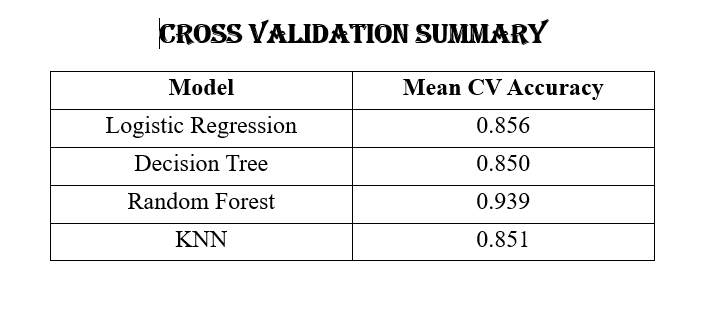


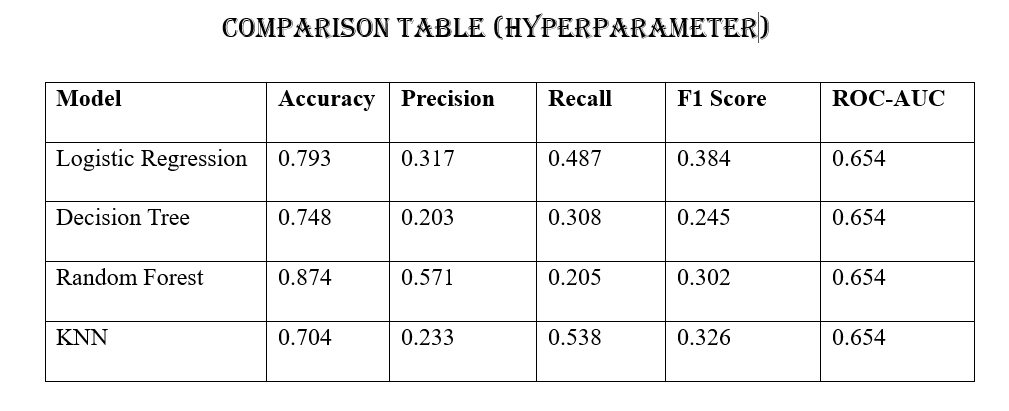


In this project, multiple machine learning classification models were developed to predict employee attrition using techniques such as data preprocessing, exploratory data analysis, feature encoding, scaling, cross-validation, and hyperparameter tuning. The models evaluated include Logistic Regression, Decision Tree, Random Forest, and KNN. Based on performance metrics, Random Forest achieved the highest accuracy of 0.874 and the best cross-validation accuracy of 0.939, indicating strong overall predictive power. However, it showed a very low recall of 0.205, meaning it failed to identify many employees who are likely to leave. On the other hand, Logistic Regression provided a more balanced performance with an accuracy of 0.793, recall of 0.487, and the highest F1 score of 0.384, making it more effective for identifying attrition cases. KNN achieved the highest recall of 0.538 but had lower overall accuracy, while Decision Tree showed comparatively lower performance across all metrics. Considering both accuracy and the importance of correctly identifying employees who may leave, Logistic Regression is selected as the most suitable model. Overall, the project demonstrates that machine learning can effectively help organizations predict employee attrition and support better decision-making for employee retention.